# Time-Dependent PDEs

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/caam37830-sci-comp/notes/blob/main/04_functions/pde_method_of_lines.ipynb)

[Boundary Value Problems](bvp.ipynb) solved PDEs that had already settled down --
the steady state, where nothing depends on time. 

In [2]:
import numpy as np
import scipy.sparse as sparse
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## The diffusion equation

We'll work with

$$\frac{\partial u}{\partial t} = D\,\frac{\partial^2 u}{\partial x^2},
\qquad x \in [0, L],$$

the equation for heat spreading along a bar, or a chemical spreading in a tube.

## Discretizing space

Put down $n$ equally spaced points $x_i$ with spacing $\Delta x$, and let $u_i(t)$
approximate $u(x_i, t)$.  The standard second-order approximation to the second
derivative is the **second difference**

$$\frac{\partial^2 u}{\partial x^2}\bigg|_{x_i}
  \approx \frac{u_{i-1} - 2u_i + u_{i+1}}{\Delta x^2},$$

which you can get by adding the Taylor expansions of $u(x_i \pm \Delta x)$.  Applied
at every point at once, this is a matrix -- tridiagonal, and very sparse, so we
build it with [`scipy.sparse`](../02_linear_algebra/sparse.ipynb) rather than as
a dense array.

In [3]:
def laplacian_1d(n, dx, bc="dirichlet"):
    """
    second-difference matrix on n equally spaced points with spacing dx

    bc controls what is assumed to sit just outside the domain:
      'dirichlet' - a ghost value of 0     (the ends are held at zero)
      'neumann'   - a copy of the neighbour (no flux through the ends)
      'periodic'  - the value at the far end (the domain is a ring)
    """
    A = sparse.diags([1, -2, 1], [-1, 0, 1], shape=(n, n), format="lil")

    if bc == "neumann":
        A[0, 0] = A[-1, -1] = -1          # ghost equals the neighbour
    elif bc == "periodic":
        A[0, -1] = A[-1, 0] = 1           # wrap around
    elif bc != "dirichlet":
        raise ValueError(f"unknown bc {bc!r}")

    return A.tocsr() / dx**2


laplacian_1d(5, 1.0).toarray()

/opt/miniconda3/envs/pycourse/lib/python3.11/site-packages/scipy/sparse/_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)


array([[-2.,  1.,  0.,  0.,  0.],
       [ 1., -2.,  1.,  0.,  0.],
       [ 0.,  1., -2.,  1.,  0.],
       [ 0.,  0.,  1., -2.,  1.],
       [ 0.,  0.,  0.,  1., -2.]])

Before using it, check it.  The second difference should turn $\sin(kx)$ into
$-k^2\sin(kx)$, so applying the matrix to a sampled sine should scale it by
roughly $-k^2$.  This takes one cell and catches sign errors, factor-of-$\Delta x$
errors, and off-by-one indexing all at once.

In [4]:
L, n = 1.0, 200
dx = L / (n + 1)
x = np.linspace(dx, L - dx, n)          # n interior points, ends held at 0

k = np.pi / L                           # sin(kx) vanishes at x = 0 and x = L
u = np.sin(k * x)
Au = laplacian_1d(n, dx) @ u

print(f"ratio (Au / u) in the middle: {Au[n // 2] / u[n // 2]:.4f}")
print(f"-k^2                        : {-k**2:.4f}")

ratio (Au / u) in the middle: -9.8694
-k^2                        : -9.8696


## From PDE to ODE

Now the whole trick.  With space discretized, $u$ is a vector and the PDE reads

$$\frac{d\mathbf{u}}{dt} = D\,A\,\mathbf{u},$$

an ODE system.  Hand it to `solve_ivp`.

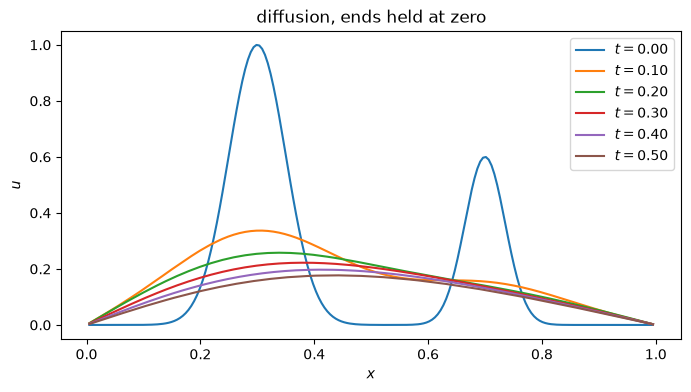

In [5]:
D, T = 0.1, 0.5
A = laplacian_1d(n, dx)

u0 = np.exp(-200 * (x - 0.3)**2) + 0.6 * np.exp(-400 * (x - 0.7)**2)

sol = solve_ivp(lambda t, u: D * (A @ u), (0, T), u0,
                t_eval=np.linspace(0, T, 6))

plt.figure(figsize=(8, 4))
for j, t in enumerate(sol.t):
    plt.plot(x, sol.y[:, j], label=f'$t = {t:.2f}$')
plt.xlabel('$x$'); plt.ylabel('$u$'); plt.legend()
plt.title('diffusion, ends held at zero')
plt.show()

Two bumps spread, merge, and drain away through the ends.  That is roughly
fifteen lines of code for a PDE solve, which is the appeal of the method.

## What the boundary conditions do

The three `bc` options differ only in what they assume sits *just outside* the
domain, but they produce qualitatively different physics.  A good way to see it
is to track the total amount of stuff, $\sum_i u_i \Delta x$.

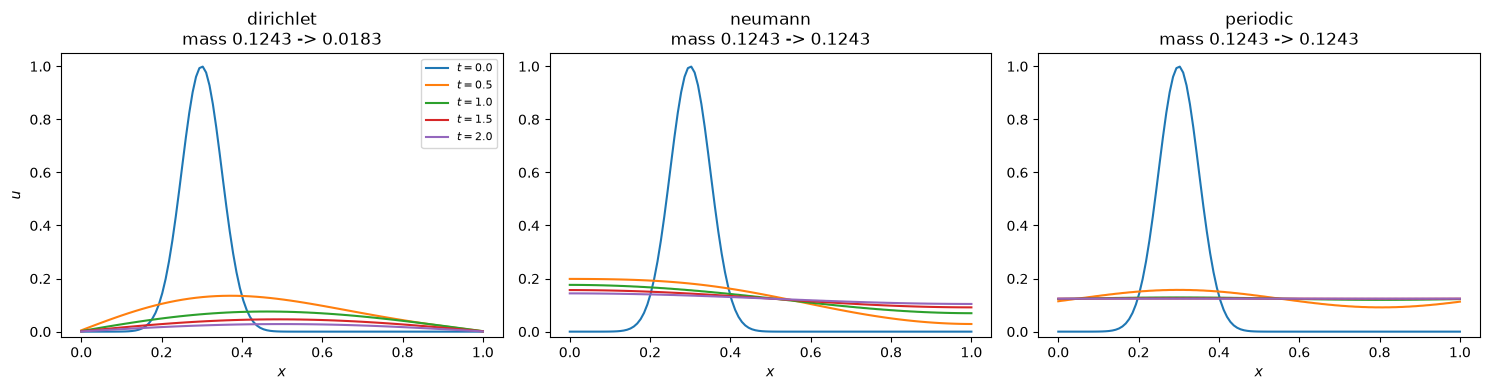

In [6]:
u0p = np.exp(-200 * (np.linspace(0, L, 120) - 0.3)**2)
xp = np.linspace(0, L, 120)
dxp = L / 120

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, bc in zip(axes, ["dirichlet", "neumann", "periodic"]):
    Ab = laplacian_1d(len(xp), dxp, bc=bc)
    s = solve_ivp(lambda t, u: D * (Ab @ u), (0, 2.0), u0p,
                  t_eval=np.linspace(0, 2.0, 5))
    for j, t in enumerate(s.t):
        ax.plot(xp, s.y[:, j], label=f'$t={t:.1f}$')
    mass0 = u0p.sum() * dxp
    massT = s.y[:, -1].sum() * dxp
    ax.set_title(f'{bc}\nmass {mass0:.4f} -> {massT:.4f}')
    ax.set_xlabel('$x$'); ax.set_ylim(-0.02, 1.05)
axes[0].set_ylabel('$u$'); axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Dirichlet leaks -- the ends are held at zero, so material leaves.  Neumann and
periodic conserve the total to several digits, because nothing can escape.

That conservation is not a coincidence, and it is the single most useful test
you can write for this kind of solver.  For Neumann and periodic boundaries the
column sums of $A$ are zero, so $\mathbf{1}^\top A = 0$, so
$\frac{d}{dt}\sum_i u_i = 0$ *exactly*, in exact arithmetic, for any initial
condition.  A test that asserts conservation to near machine precision will pass
for a correct implementation and fail for almost any indexing slip.

In [7]:
for bc in ["neumann", "periodic"]:
    col_sums = np.abs(np.asarray(laplacian_1d(50, 0.02, bc=bc).sum(axis=0))).max()
    print(f"{bc:10} max |column sum| = {col_sums:.2e}")
print(f"{'dirichlet':10} max |column sum| = "
      f"{np.abs(np.asarray(laplacian_1d(50, 0.02).sum(axis=0))).max():.2e}"
      "   <- leaks at the ends, as it should")

neumann    max |column sum| = 0.00e+00
periodic   max |column sum| = 0.00e+00
dirichlet  max |column sum| = 2.50e+03   <- leaks at the ends, as it should


## Stability: why the time step is not yours to choose

`solve_ivp` picked its own time steps above.  Suppose instead we step forward by
hand with the simplest possible scheme, explicit Euler:

$$\mathbf{u}^{m+1} = \mathbf{u}^m + \Delta t\, D A \mathbf{u}^m.$$

Each step multiplies by $I + \Delta t D A$.  Writing $\mathbf{u}$ in the
eigenbasis of $A$, the component belonging to eigenvalue $\lambda$ is multiplied
by $1 + \Delta t D \lambda$ every step, so it stays bounded only if

$$|1 + \Delta t\, D \lambda| \le 1 .$$

The eigenvalues of the second-difference matrix run from near $0$ down to about
$-4/\Delta x^2$, and it is that most negative one -- the most oscillatory mode,
the sawtooth -- that binds.  Plugging it in gives

$$\Delta t \le \frac{\Delta x^2}{2D}.$$

Note what this says: **halving $\Delta x$ forces you to quarter $\Delta t$.**  Refining
the mesh gets expensive fast.  Let's watch the threshold bite.

In [8]:
n2 = 40
dx2 = L / (n2 + 1)
x2 = np.linspace(dx2, L - dx2, n2)
A2 = laplacian_1d(n2, dx2)
dt_max = dx2**2 / (2 * D)

# a spike excites every mode, including the one that goes unstable
spike = np.zeros(n2)
spike[n2 // 2] = 1.0

print(f"dx = {dx2:.5f},  dt_max = dx^2/(2D) = {dt_max:.3e}\n")
for factor in [0.5, 0.9, 1.05, 1.2]:
    dt = factor * dt_max
    u = spike.copy()
    nsteps = int(0.2 / dt)
    for _ in range(nsteps):
        u = u + dt * D * (A2 @ u)
    print(f"  dt = {factor:>4} * dt_max   {nsteps:4d} steps   "
          f"max|u| = {np.max(np.abs(u)):.3e}")

dx = 0.02439,  dt_max = dx^2/(2D) = 2.974e-03

  dt =  0.5 * dt_max    134 steps   max|u| = 4.869e-02
  dt =  0.9 * dt_max     74 steps   max|u| = 4.873e-02
  dt = 1.05 * dt_max     64 steps   max|u| = 2.272e+01
  dt =  1.2 * dt_max     56 steps   max|u| = 8.743e+06


Below the threshold the answer is a sensible $\sim 0.05$.  A 5% overshoot gives
$22$, and a 20% overshoot gives $10^7$.  There is no gentle degradation: the
scheme is fine until it is catastrophically not.

The amplification factors say exactly why.

In [9]:
lam_max = -4 / dx2**2 * np.sin(np.pi * n2 / (2 * (n2 + 1)))**2
print("amplification of the most oscillatory mode, 1 + dt*D*lambda_max:\n")
for factor in [0.5, 0.9, 1.05, 1.2]:
    g = 1 + factor * dt_max * D * lam_max
    flag = "" if abs(g) <= 1 else "   <- |g| > 1, grows every step"
    print(f"  dt = {factor:>4} * dt_max   g = {g:+.3f}{flag}")

amplification of the most oscillatory mode, 1 + dt*D*lambda_max:

  dt =  0.5 * dt_max   g = +0.001
  dt =  0.9 * dt_max   g = -0.797
  dt = 1.05 * dt_max   g = -1.097   <- |g| > 1, grows every step
  dt =  1.2 * dt_max   g = -1.396   <- |g| > 1, grows every step


This is why `solve_ivp` was a reasonable thing to reach for: it adapts its step
to keep the error in check.  But note that for a fine mesh, an *explicit* solver
is forced into tiny steps by stability rather than by accuracy -- the problem is
**stiff**.  That is the moment to switch to an implicit method, which has no such
restriction; `solve_ivp(..., method='BDF')` and passing the Jacobian `D*A` is
the usual move, and it is the reason we built $A$ as a sparse matrix.

## Is it actually second order?

Everything above produces plausible pictures.  Plausible pictures are exactly
what a subtly wrong discretization also produces, so let's do the test that
actually discriminates.

Take an initial condition whose exact solution we know.  With ends held at zero
and $u(x, 0) = \sin(\pi x/L)$, separation of variables gives

$$u(x, t) = e^{-D(\pi/L)^2 t}\,\sin(\pi x/L).$$

Solve numerically on a sequence of meshes, measure the error, and check that it
falls like $\Delta x^2$.  If the claimed second-order stencil is really only first
order -- a single misplaced index will do it -- this is where it shows up, and
nowhere else.

In [10]:
def diffusion_error(n, T=0.5):
    """
    max error at time T against the exact solution, on n interior points
    """
    dx = L / (n + 1)
    x = np.linspace(dx, L - dx, n)
    A = laplacian_1d(n, dx)
    u0 = np.sin(np.pi * x / L)

    # time error driven far below the spatial error we are trying to measure
    sol = solve_ivp(lambda t, u: D * (A @ u), (0, T), u0,
                    t_eval=[T], rtol=1e-11, atol=1e-13)

    exact = np.exp(-D * (np.pi / L)**2 * T) * np.sin(np.pi * x / L)
    return dx, np.max(np.abs(sol.y[:, -1] - exact))


ns = [10, 20, 40, 80, 160]
dxs, errs = zip(*[diffusion_error(n) for n in ns])

for n, d, e in zip(ns, dxs, errs):
    print(f"  n = {n:4d}   dx = {d:.5f}   error = {e:.3e}")

slope = np.polyfit(np.log(dxs), np.log(errs), 1)[0]
print(f"\nfitted order: {slope:.3f}   (expected 2)")

  n =   10   dx = 0.09091   error = 2.025e-03
  n =   20   dx = 0.04762   error = 5.601e-04
  n =   40   dx = 0.02439   error = 1.473e-04
  n =   80   dx = 0.01235   error = 3.776e-05
  n =  160   dx = 0.00621   error = 9.559e-06

fitted order: 1.996   (expected 2)


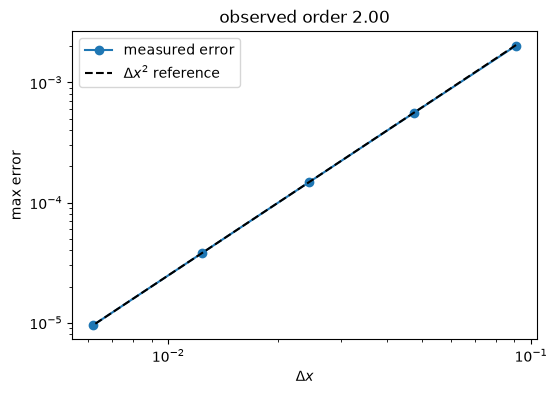

In [11]:
plt.figure(figsize=(6, 4))
plt.loglog(dxs, errs, 'o-', label='measured error')
plt.loglog(dxs, np.array(dxs)**2 * errs[-1] / dxs[-1]**2, 'k--',
           label=r'$\Delta x^2$ reference')
plt.xlabel(r'$\Delta x$'); plt.ylabel('max error'); plt.legend()
plt.title(f'observed order {slope:.2f}')
plt.show()

A slope of 2 on a log-log plot is the evidence.  Note how much stronger a claim
it is than "the picture looks like diffusion": it pins down the *rate*, and the
rate is what the derivation promised.  Get in the habit of producing this plot
for any discretization you write or are handed -- it is quick, and it is the
thing that catches errors a plot of the solution never will.

## Animating the solution

Snapshots are fine, but a time-dependent solution is easier to read moving.

In [19]:
from matplotlib import animation
from IPython.display import HTML

sol = solve_ivp(lambda t, u: D * (A @ u), (0, T), u0,
                t_eval=np.linspace(0, T, 40))

fig, ax = plt.subplots(figsize=(6, 3), dpi=72)
line, = ax.plot(x, sol.y[:, 0])
ax.set_xlim(0, L); ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('$x$'); ax.set_ylabel('$u$')
title = ax.set_title('$t = 0.00$')


def frame(j):
    line.set_ydata(sol.y[:, j])
    title.set_text(f'$t = {sol.t[j]:.2f}$')
    return line, title


anim = animation.FuncAnimation(fig, frame, frames=len(sol.t), interval=80, blit=False)
anim.save('diffusion.gif', writer='pillow')
plt.close(fig)          # keep the static figure from also being displayed
HTML(anim.to_jshtml())



`FuncAnimation` redraws by mutating the artists you already created rather than
re-plotting, which is why `frame` calls `set_ydata` instead of `ax.plot`.  In a
notebook, `to_jshtml` embeds the frames with a little player; to write a file
instead use `anim.save('diffusion.gif', writer='pillow')`.  The same machinery
drives the Game of Life animation in
[Agent Based Models](../09_computing/agent_based_models.ipynb).

## Exercises

### Exercise 1

Rerun the convergence study with a deliberately broken stencil -- change the
`[1, -2, 1]` coefficients to `[1, -2, 1.05]`, say, or shift one of the offsets.
What order do you measure?

Then do the same with the *correct* stencil but a loose `rtol=1e-3` in
`solve_ivp`.  You should find the measured order collapses for a reason that has
nothing to do with the spatial discretization.  Explain what happened.

In [ ]:
# Your code here


### Exercise 2

Write a unit test (see [Unit Testing](../09_computing/unittest.ipynb)) asserting
that with periodic boundaries the total $\sum_i u_i \Delta x$ is conserved to
within `1e-10` over 100 steps, for a random initial condition.

Now break `laplacian_1d` in a small way -- drop the `A[-1, 0] = 1` wrap-around
term -- and confirm your test catches it.

In [ ]:
# Your code here


### Exercise 3

The **wave equation** $u_{tt} = c^2 u_{xx}$ is second order in time.  Convert it to
a first-order system by introducing $v = u_t$:

$$\frac{d}{dt}\begin{pmatrix} u \\ v \end{pmatrix}
 = \begin{pmatrix} v \\ c^2 A u\end{pmatrix},$$

and solve it with `solve_ivp` from an initial bump at rest.  Animate it.

Unlike diffusion, the wave equation conserves energy
$E = \tfrac12\sum_i (v_i^2 + c^2 (\partial_x u)_i^2)\Delta x$.  Track $E$ over time.
Does the default `RK45` preserve it?  Should it?

In [ ]:
# Your code here


### Exercise 4

Add a reaction term to get a **reaction-diffusion** equation,

$$u_t = D u_{xx} + u(1 - u),$$

which is the Fisher-KPP equation.  Start from a small bump on the left of a long
domain and watch it invade.  You should see a front that settles to a fixed
shape moving at constant speed; measure that speed and compare it to the
theoretical $2\sqrt{D}$.

This is another instance of the pattern from this section: the interesting
quantity to check is not the solution values but an invariant of the solution.

In [ ]:
# Your code here
